# Rosenblatt ordering in system reliability

Reproduce the Meinen–Steenbergen ordering example and distinguish coordinate changes from changes in the physical failure event.

**Before you start:** the dependence and system-reliability tutorials.

## Problem and approach

This tutorial reproduces selected results from **Nadieh Meinen and Raphaël Steenbergen (2025), “Application of the Rosenblatt transformation in First-Order System Reliability approximations,” Structural Safety 112, 102521**. [Read the paper](https://doi.org/10.1016/j.strusafe.2024.102521).

Their work shows how the conditioning order used in a Rosenblatt transformation can affect first-order **system** reliability, and why combining component analyses made with different orders requires care. We follow their Example 1, including its fully dependent and independent two-component series systems. The example extends the component benchmark studied by [Lebrun and Dutfoy (2009)](https://doi.org/10.1016/j.probengmech.2009.04.006).

The examples and research question are credited to those authors. The code, numerical integrations and plots below are computed afresh with PySTRA. Gaussian coordinate alignment and integration in both directions provide additional implementation checks. This notebook does not reproduce the paper's larger nonlinear parametric study in Example 2.

Read [copulas and transformations](ex_copulas.ipynb) and [system reliability](ex_system_reliability.ipynb) for the underlying PySTRA APIs.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.integrate import quad
from scipy.stats import expon, norm
import pystra as ra

pd.set_option("display.precision", 6)
orders = {"Canonical": [0, 1], "Reverse": [1, 0]}
colors = {"Canonical": "#176b87", "Reverse": "#9b4f96"}
copulas = {
    "Gaussian": ra.GaussianCopula([[1, 0.5], [0.5, 1]]),
    "Frank": ra.FrankCopula(4.73),
}


def make_joint(copula):
    return ra.JointDistribution(
        [
            ra.ScipyDist("X1", expon(scale=1)),
            ra.ScipyDist("X2", expon(scale=1 / 3)),
        ],
        copula,
    )


def limit_state(X1, X2):
    return 8 * X1 + 2 * X2 - 1


def make_options(order, method="rosenblatt"):
    options = ra.FORMOptions(transform=method, rosenblatt_order=order)
    return options


## The component and its joint probability model

The component failure event is

$$g(X_1,X_2)=8X_1+2X_2-1\leq 0,$$

with exponential marginal rates $\lambda_1=1$ and $\lambda_2=3$. We use either a Gaussian copula with **latent correlation** $\rho=0.5$, or a Frank copula with $\theta=4.73$, as in Meinen and Steenbergen's Example 1. The earlier Lebrun–Dutfoy example uses $\theta=10$; changing that parameter changes the problem.

The joint law stays fixed while we change the Rosenblatt order:

- **Canonical:** first transform $X_1$, then transform $X_2$ conditional on $X_1$.
- **Reverse:** first transform $X_2$, then transform $X_1$ conditional on $X_2$.

PySTRA stores the normal coordinates in original variable positions. Thus a coordinate labeled $u_1$ has a different conditional meaning in the two orders. Matching labels do not establish matching coordinates.

In [2]:
components = {}
rows = []
for name, copula in copulas.items():
    for label, order in orders.items():
        form = ra.FORM(
            model=ra.StochasticModel(make_joint(copula)),
            limit_state=ra.LimitState(limit_state),
            options=make_options(order),
        )
        result = form.run()
        assert result.converged
        components[name, label] = (form, result)
        rows.append(
            {
                "copula": name,
                "order": label,
                "beta": result.beta,
                "FORM probability": result.failure_probability,
                "alpha": tuple(np.round(result.alpha, 6)),
            }
        )
component_table = pd.DataFrame(rows).set_index(["copula", "order"])
component_table


beta  FORM probability                   alpha
copula   order                                                        
Gaussian Canonical  1.295457          0.097581  (-0.991823, -0.127619)
         Reverse    1.295457          0.097581  (-0.795134, -0.606433)
Frank    Canonical  1.270281          0.101992  (-0.995807, -0.091477)
         Reverse    1.204093          0.114277  (-0.725144, -0.688598)

The Gaussian probabilities agree at about 0.09758, although the alpha vectors differ. Frank gives about 0.10199 and 0.11428: a different first-order approximation to the **same** probability model. These reproduce the component results underlying the paper's Figures 1 and 2. PySTRA's alpha vectors point toward failure; the paper reports positive direction-cosine magnitudes for this example.

The next figure follows the geometric comparison in the paper's Figure 1. Each solid curve is the original physical failure boundary mapped into one set of independent normal coordinates. Dashed lines are the FORM tangent approximations; dots mark design points. Equal axis scales matter when comparing distance from the origin.

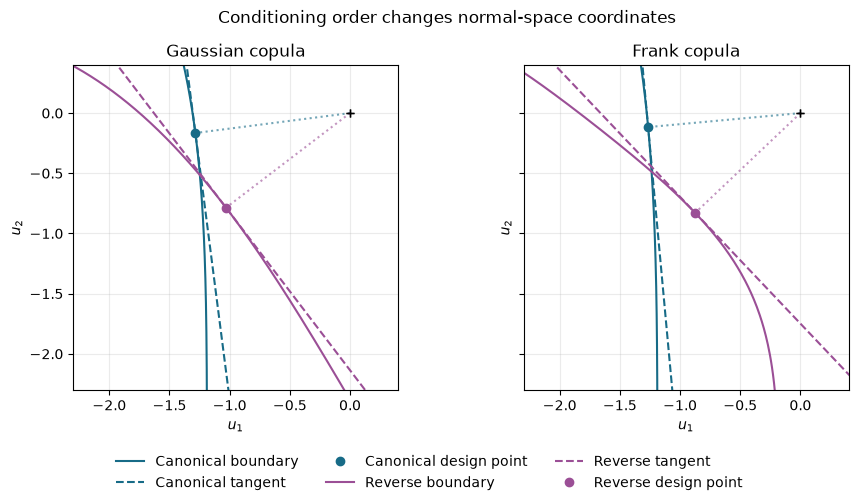

In [3]:
x1 = np.linspace(1e-7, 1 / 8 - 1e-7, 600)
physical_boundary = np.column_stack([x1, (1 - 8 * x1) / 2])
fig, axes = plt.subplots(1, 2, figsize=(11, 5), sharex=True, sharey=True)
for ax, name in zip(axes, copulas):
    for label in orders:
        form, result = components[name, label]
        boundary = np.array([form.transform.x_to_u(x) for x in physical_boundary])
        ra.plotting.plot_form_geometry(
            result,
            boundary=boundary,
            label=label,
            color=colors[label],
            ax=ax,
        )
    ax.set(xlim=(-2.3, 0.4), ylim=(-2.3, 0.4), title=name + " copula")
    ax.grid(alpha=0.25)
    ax.get_legend().remove()
handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, loc="lower center", ncol=3, frameon=False)
fig.suptitle("Conditioning order changes normal-space coordinates", y=0.98)
fig.subplots_adjust(bottom=0.22, top=0.87, wspace=0.12)
plt.show()


**Figure.** Canonical and reversed conditioning orders map the same physical boundary differently. Gaussian mappings preserve distances by rotation or reflection; Frank mappings alter the local FORM geometry.

For a Gaussian copula, the two mappings differ by an orthogonal transformation: they rotate or reflect the same normal-space geometry. FORM distances and consistently computed system correlations are preserved, up to solver accuracy.

For Frank, the change of coordinates is nonlinear. A tangent plane in one coordinate system is generally not a tangent **plane** after that nonlinear transformation. Specifying the copula exactly therefore does not remove order sensitivity from FORM's approximation.

## Two fully dependent identical components

Meinen and Steenbergen first consider identical components whose corresponding variables are perfectly dependent. Represent them using **one shared pair** $(X_1,X_2)$, rather than introducing duplicate random variables and a singular four-variable correlation matrix.

$$F_1=F_2=\{8X_1+2X_2-1\leq0\},\qquad
P(F_1\cup F_2)=P(F_1).$$

This is an important system identity. `SystemFORM` evaluates both components using one complete model and one transformation configuration.

In [4]:
systems = {}
rows = []
for name, copula in copulas.items():
    for label, order in orders.items():
        system = ra.SystemFORM(
            ra.StochasticModel(make_joint(copula)),
            ra.SeriesSystem(
                [
                    ra.Component("first", limit_state),
                    ra.Component("second", limit_state),
                ]
            ),
            options=make_options(order),
        )
        system_result = system.run()
        assert system_result.converged
        assert system_result.correlation[0, 1] == 1
        assert np.isclose(system_result.failure_probability, system_result.component_results["first"].failure_probability, atol=1e-12)
        systems[name, label] = system_result
        rows.append(
            {
                "copula": name,
                "order": label,
                "component probability": system_result.component_results["first"].failure_probability,
                "system probability": system_result.failure_probability,
                "tangent-score correlation": system_result.correlation[0, 1],
            }
        )
pd.DataFrame(rows).set_index(["copula", "order"])


component probability  system probability  \
copula   order                                                  
Gaussian Canonical               0.097581            0.097581   
         Reverse                 0.097581            0.097581   
Frank    Canonical               0.101992            0.101992   
         Reverse                 0.114277            0.114277   

                    tangent-score correlation  
copula   order                                 
Gaussian Canonical                        1.0  
         Reverse                          1.0  
Frank    Canonical                        1.0  
         Reverse                          1.0

The identity is preserved for both copulas and both orders. Frank still has two different approximations, each consistent with its own component analysis. Sharing the transformation fixes consistency between components; it does not make the approximation exact.

## Reproduce the mixed-coordinate pitfall

The paper also combines a canonical component analysis with a reverse one. For shared variables, treating their alpha vectors as if they occupied the same normal coordinate system gives

$$\rho_{\mathrm{mixed}}=\boldsymbol{\alpha}^{C}\cdot\boldsymbol{\alpha}^{R}<1.$$

This would incorrectly imply that the two identical failure events can occur separately. We deliberately reproduce that calculation below as an **anti-example**, outside `SystemFORM`. The bivariate normal integral computes what the inconsistent tangent model predicts; it is not the probability of the specified physical system.

In [5]:
def normal_intersection(beta1, beta2, rho):
    return quad(
        lambda u: norm.pdf(u) * norm.cdf((-beta2 - rho * u) / np.sqrt(1 - rho**2)),
        -np.inf,
        -beta1,
        epsabs=1e-11,
    )[0]


mixed = {}
rows = []
for name in copulas:
    canonical, reverse = (components[name, label][1] for label in orders)
    rho = float(np.asarray(canonical.alpha) @ np.asarray(reverse.alpha))
    probability = (
        canonical.failure_probability
        + reverse.failure_probability
        - normal_intersection(canonical.beta, reverse.beta, rho)
    )
    mixed[name] = probability
    rows.append(
        {
            "copula": name,
            "unaligned alpha product": rho,
            "invalid mixed system probability": probability,
        }
    )
pd.DataFrame(rows).set_index("copula")


,unaligned alpha product,invalid mixed system probability
copula,,
Gaussian,0.866025,0.132892
Frank,0.785094,0.156408


The resulting probabilities, approximately **0.133 for Gaussian** and **0.156 for Frank**, reproduce the mixed dependent-system results in the paper. Both violate the identical-event identity.

For Gaussian coordinates we can demonstrate the repair explicitly. Let $u^C=A_C z$ and $u^R=A_R z$, where $z$ contains the marginal normal scores. Then

$$Q=A_R A_C^{-1},\qquad QQ^T=I,\qquad
\alpha^R_{\text{expressed in C}}=Q^T\alpha^R.$$

Aligning the Gaussian alpha vectors restores correlation one. Simply permuting their labels would not generally accomplish this. The shared transformation used by `SystemFORM` avoids needing this repair in normal use.

In [6]:
gaussian = copulas["Gaussian"]
matrices = {}
for label, order in orders.items():
    matrices[label] = np.column_stack(
        [norm.ppf(gaussian.rosenblatt(norm.cdf(z), order)) for z in np.eye(2)]
    )
rotation = matrices["Reverse"] @ np.linalg.inv(matrices["Canonical"])
assert np.allclose(rotation @ rotation.T, np.eye(2), atol=1e-12)
alpha_c = np.asarray(components["Gaussian", "Canonical"][1].alpha)
alpha_r = np.asarray(components["Gaussian", "Reverse"][1].alpha)
aligned_r = rotation.T @ alpha_r
assert np.allclose(aligned_r, alpha_c, atol=1e-8)
print("Before alignment:", float(alpha_c @ alpha_r))
print("After alignment: ", float(alpha_c @ aligned_r))


Before alignment: 0.8660254037844353
After alignment:  0.9999999999999998


There is no equivalent single global orthogonal matrix for the Frank transformation. The normal-space tangent model itself changes with order.

## A reference from the original failure event

The physical event can be integrated directly without a FORM approximation:

$$P_f=\int_0^{1/8} e^{-x}\,
F_{X_2\mid X_1=x}\!\left(\frac{1-8x}{2}\right)\,dx.$$

We also integrate along $X_2$. Both conditioning orders must give the same original-event probability, even when the corresponding FORM approximations differ. This checks the joint law separately from the tangent approximation.

In [7]:
def original_probability(copula, order):
    i, j = order
    rates, weights = (1, 3), (8, 2)

    def integrand(x):
        probabilities = np.empty(2)
        probabilities[i] = -np.expm1(-rates[i] * x)
        boundary = (1 - weights[i] * x) / weights[j]
        probabilities[j] = -np.expm1(-rates[j] * boundary)
        conditional = copula.rosenblatt(probabilities, order=order)[j]
        return rates[i] * np.exp(-rates[i] * x) * conditional

    value, integration_error = quad(integrand, 0, 1 / weights[i], epsabs=1e-11)
    return value


references = {}
rows = []
for name, copula in copulas.items():
    values = [original_probability(copula, order) for order in orders.values()]
    assert np.isclose(values[0], values[1], atol=1e-10, rtol=0)
    references[name] = values[0]
    rows.append(
        {
            "copula": name,
            "integrate along X1": values[0],
            "integrate along X2": values[1],
        }
    )
pd.DataFrame(rows).set_index("copula")


,integrate along X1,integrate along X2
copula,,
Gaussian,0.087185,0.087185
Frank,0.093225,0.093225


**Reproduction note.** Section 3.3 of Meinen and Steenbergen lists dependent-case Monte Carlo probabilities 0.0932 for Gaussian and 0.0872 for Frank. These appear interchanged: using the stated parameters, direct integration gives **Gaussian 0.0871846** and **Frank 0.0932253**. The direct sampling check below supports those assignments. We retain the paper's stated model and distinguish our computed reference from its printed values.

## Independent copies and direct simulation

The other limiting case in Example 1 has two independent copies of the component pair. Each pair retains its within-component Gaussian or Frank dependence; the pairs are independent of one another.

$$P(F_1\cup F_2)=1-(1-P_f)^2.$$

For this case we can combine component probabilities analytically. The Frank law for four variables is the **product of two bivariate Frank copulas**. Applying a single four-dimensional Frank copula would specify a different dependence model. PySTRA currently exposes bivariate Frank directly, so we use the independent-copy formula and sample two independent pairs explicitly.

The Monte Carlo calculation evaluates the original limit states on samples from the joint law. Its 95 % intervals below use the binomial normal approximation, appropriate to the sample size and probabilities in this example. The integration reference supplies the more precise check.

In [8]:
draws = 250_000
seeds = np.random.SeedSequence(20260906).spawn(len(copulas))
monte_carlo = {}
rows = []
for (name, copula), seed in zip(copulas.items(), seeds):
    samples = make_joint(copula).rvs(2 * draws, seed=np.random.default_rng(seed))
    first = limit_state(samples[:draws, 0], samples[:draws, 1]) <= 0
    second = limit_state(samples[draws:, 0], samples[draws:, 1]) <= 0
    for case, events, reference in (
        ("Shared event", first, references[name]),
        ("Independent copies", first | second, 1 - (1 - references[name]) ** 2),
    ):
        estimate = events.mean()
        standard_error = np.sqrt(estimate * (1 - estimate) / draws)
        monte_carlo[name, case] = (estimate, standard_error)
        rows.append(
            {
                "copula": name,
                "system": case,
                "integration reference": reference,
                "Monte Carlo": estimate,
                "95% lower": estimate - 1.96 * standard_error,
                "95% upper": estimate + 1.96 * standard_error,
            }
        )
pd.DataFrame(rows).set_index(["copula", "system"])


integration reference  Monte Carlo  95% lower  \
copula   system                                                              
Gaussian Shared event                     0.087185     0.086588   0.085486   
         Independent copies               0.166768     0.166256   0.164797   
Frank    Shared event                     0.093225     0.092056   0.090923   
         Independent copies               0.177760     0.176728   0.175233   

                             95% upper  
copula   system                         
Gaussian Shared event         0.087690  
         Independent copies   0.167715  
Frank    Shared event         0.093189  
         Independent copies   0.178223

In [9]:
summary = []
for name in copulas:
    for label in orders:
        p = components[name, label][1].failure_probability
        summary.append(
            {
                "copula": name,
                "order": label,
                "shared-event FORM": systems[name, label].failure_probability,
                "independent-copy FORM": 1 - (1 - p) ** 2,
            }
        )
pd.DataFrame(summary).set_index(["copula", "order"])


shared-event FORM  independent-copy FORM
copula   order                                              
Gaussian Canonical           0.097581               0.185640
         Reverse             0.097581               0.185640
Frank    Canonical           0.101992               0.193582
         Reverse             0.114277               0.215495

The final plot follows the system comparison in the paper's Figure 2, adding the direct integration reference and sampling intervals. The red cross is the deliberately invalid mixed-coordinate calculation for the shared-event case. The independent-copy points use the product formula above.

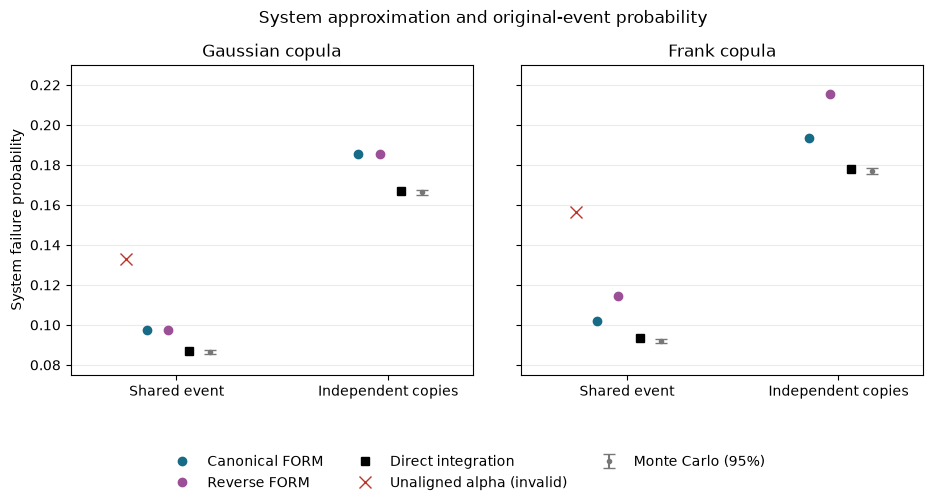

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(11, 5), sharey=True)
system_labels = ["Shared event", "Independent copies"]
for ax, name in zip(axes, copulas):
    for label, offset in (("Canonical", -0.14), ("Reverse", -0.04)):
        p = components[name, label][1].failure_probability
        ax.plot(
            np.arange(2) + offset,
            [p, 1 - (1 - p) ** 2],
            "o",
            color=colors[label],
            label=label + " FORM",
        )
    exact = [references[name], 1 - (1 - references[name]) ** 2]
    ax.plot(np.arange(2) + 0.06, exact, "s", color="black", label="Direct integration")
    estimates, errors = np.array(
        [monte_carlo[name, label] for label in system_labels]
    ).T
    ax.errorbar(
        np.arange(2) + 0.16,
        estimates,
        yerr=1.96 * errors,
        fmt=".",
        color="#777777",
        capsize=4,
        label="Monte Carlo (95%)",
    )
    ax.plot(
        -0.24,
        mixed[name],
        "x",
        color="#bc352b",
        markersize=9,
        label="Unaligned alpha (invalid)",
    )
    ax.set(
        xticks=[0, 1],
        xticklabels=system_labels,
        xlim=(-0.5, 1.4),
        ylim=(0.075, 0.23),
        title=name + " copula",
    )
    ax.grid(axis="y", alpha=0.25)
axes[0].set_ylabel("System failure probability")
handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, loc="lower center", ncol=3, frameon=False)
fig.suptitle("System approximation and original-event probability", y=0.98)
fig.subplots_adjust(bottom=0.25, top=0.87, wspace=0.12)
plt.show()


**Figure.** Consistent system calculations, mixed-order tangent models and original-event references are compared. Sampling intervals describe the Monte Carlo estimates; mixed coordinates violate event consistency.

## Implications for reliability work

Meinen and Steenbergen's central lesson remains relevant with explicit copulas:

- **Specify the complete joint law.** A copula fixes dependence; conditioning order then changes coordinates, not that law. Distinguish within-component dependence from dependence across components.
- **Use a common coordinate system for shared variables.** Independently obtained alpha vectors require transformation provenance before system aggregation. Original variable names alone are insufficient.
- **Check approximation sensitivity.** Non-Gaussian Rosenblatt orders can give different first-order approximations even when every component uses a consistent order. Trying several orders is a diagnostic, not a certified probability bound or a guarantee that the largest estimate is conservative.
- **Validate the original event where practical.** Direct integration or simulation provides a check that does not inherit FORM's tangent-plane approximation.

The paper's nonlinear Example 2 is a valuable next benchmark. Its component autocorrelation formulation should be reproduced with its assumptions identified explicitly, alongside any alternative calculation using a fully specified joint model.

## References

1. **Meinen, N. E., and Steenbergen, R. D. J. M. (2025).** Application of the Rosenblatt transformation in First-Order System Reliability approximations. *Structural Safety*, **112**, 102521. [doi:10.1016/j.strusafe.2024.102521](https://doi.org/10.1016/j.strusafe.2024.102521). Main source for this tutorial: Example 1, Figures 1–2, and the discussion of mixed conditioning orders.
2. **Lebrun, R., and Dutfoy, A. (2009).** Do Rosenblatt and Nataf isoprobabilistic transformations really differ? *Probabilistic Engineering Mechanics*, **24**, 577–584. [doi:10.1016/j.probengmech.2009.04.006](https://doi.org/10.1016/j.probengmech.2009.04.006). Earlier component-level example; also reproduced in the [copula tutorial](ex_copulas.ipynb).

**Continue:** [User guide](../copulas.rst) · [API reference](../api/probability.rst) · [Theory](../theory/transformations.rst)